#### IMPORT LIBRARIES

In [36]:
# BASIC
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# TRAIN/TEST SPLIT
from sklearn.model_selection import train_test_split

# MODELS
import xgboost as xgb
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

# EVALUATION 
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.metrics import roc_curve, roc_auc_score

from sklearn.metrics import precision_score, recall_score, f1_score


#### LOAD DATA

In [37]:
# LOAD DATA
df = pd.read_csv("Loan_Default.csv")

df.head()
print(df.shape)

(148670, 31)


####  DATA CLEANING & EXPLORATORY DATA ANALYSIS

In [38]:
# Calculate missing value percentage
missing_percentage = (df.isnull().sum() / len(df)) * 100
print(missing_percentage)

ID                            0.000000
year                          0.000000
loan_limit                    2.249277
Gender                        0.000000
approv_in_adv                 0.610749
loan_type                     0.000000
loan_purpose                  0.090133
Credit_Worthiness             0.000000
open_credit                   0.000000
business_or_commercial        0.000000
loan_amount                   0.000000
rate_of_interest             24.509989
term                          0.027578
Neg_ammortization             0.081388
interest_only                 0.000000
lump_sum_payment              0.000000
property_value               10.155378
construction_type             0.000000
occupancy_type                0.000000
Secured_by                    0.000000
total_units                   0.000000
income                        6.154571
Credit_Score                  0.000000
co-applicant_credit_type      0.000000
age                           0.134526
submission_of_application

In [39]:
# CHECK UNIQUE VALUES IN EACH COLUMN
 
def find_unique_values(df):
    unique_values = {}  
    for col in df.columns:  
        unique_values[col] = df[col].nunique() 

    return unique_values  

unique_values_dict = find_unique_values(df)

for col, values in unique_values_dict.items():
    print(f"Unique values in column '{col}':\n{values}\n")

Unique values in column 'ID':
148670

Unique values in column 'year':
1

Unique values in column 'loan_limit':
2

Unique values in column 'Gender':
4

Unique values in column 'approv_in_adv':
2

Unique values in column 'loan_type':
3

Unique values in column 'loan_purpose':
4

Unique values in column 'Credit_Worthiness':
2

Unique values in column 'open_credit':
2

Unique values in column 'business_or_commercial':
2

Unique values in column 'loan_amount':
211

Unique values in column 'rate_of_interest':
131

Unique values in column 'term':
26

Unique values in column 'Neg_ammortization':
2

Unique values in column 'interest_only':
2

Unique values in column 'lump_sum_payment':
2

Unique values in column 'property_value':
385

Unique values in column 'construction_type':
2

Unique values in column 'occupancy_type':
3

Unique values in column 'Secured_by':
2

Unique values in column 'total_units':
4

Unique values in column 'income':
1001

Unique values in column 'Credit_Score':
401

Uni

In [40]:
# COLUMN NAMES CLEANING
 
df.columns = df.columns.str.strip().str.lower()

# Assign target(dependent variable)
y = df['status']

df.drop(columns=['id', 'status'], inplace=True)
df.columns

Index(['year', 'loan_limit', 'gender', 'approv_in_adv', 'loan_type',
       'loan_purpose', 'credit_worthiness', 'open_credit',
       'business_or_commercial', 'loan_amount', 'rate_of_interest', 'term',
       'neg_ammortization', 'interest_only', 'lump_sum_payment',
       'property_value', 'construction_type', 'occupancy_type', 'secured_by',
       'total_units', 'income', 'credit_score', 'co-applicant_credit_type',
       'age', 'submission_of_application', 'ltv', 'region', 'security_type',
       'dtir1'],
      dtype='object')

In [41]:
## DATA TYPES CLASSIFICATION

print("Data Types of df:\n", df.dtypes, "\n")

categorical_cols = df.select_dtypes(include=['object', 'bool']).columns.tolist()
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

print("Categorical Columns:", categorical_cols)
print("Numerical Columns:", numerical_cols)

Data Types of df:
 year                           int64
loan_limit                    object
gender                        object
approv_in_adv                 object
loan_type                     object
loan_purpose                  object
credit_worthiness             object
open_credit                   object
business_or_commercial        object
loan_amount                    int64
rate_of_interest             float64
term                         float64
neg_ammortization             object
interest_only                 object
lump_sum_payment              object
property_value               float64
construction_type             object
occupancy_type                object
secured_by                    object
total_units                   object
income                       float64
credit_score                   int64
co-applicant_credit_type      object
age                           object
submission_of_application     object
ltv                          float64
region             

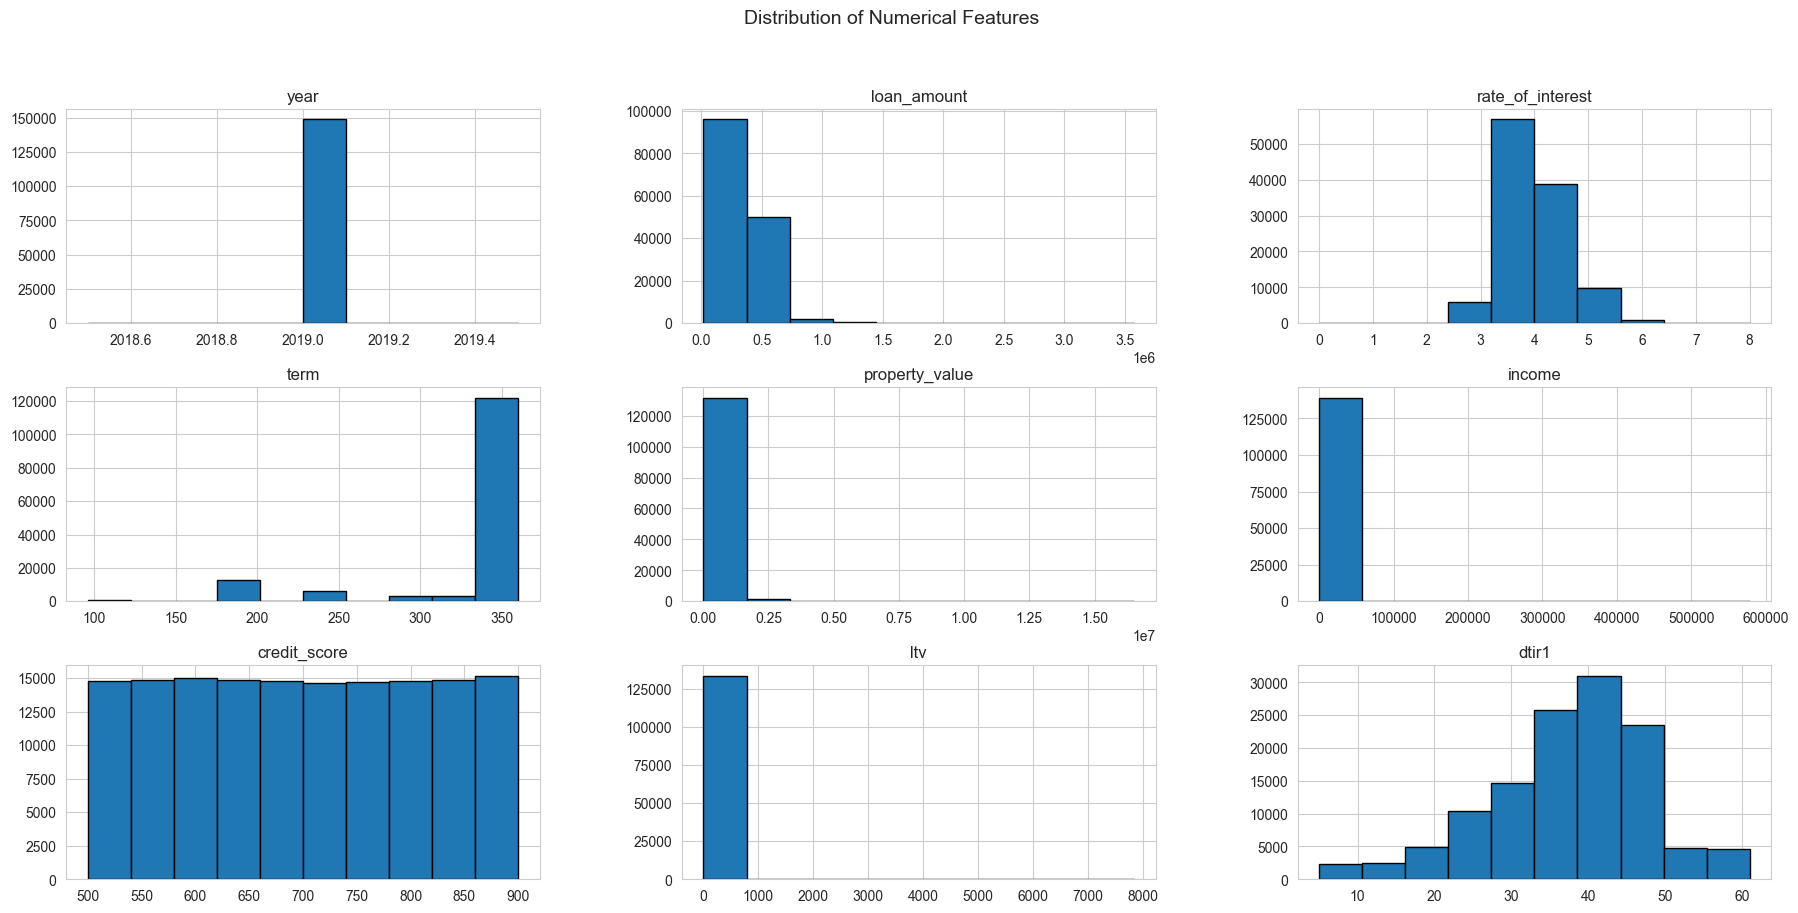

In [42]:
# HISTOGRAMS - NUMERICAL FEATURES

sns.set_style("whitegrid")

df[numerical_cols].hist(figsize=(22, 10), bins=10, edgecolor='black')
plt.suptitle("Distribution of Numerical Features", fontsize=14)
plt.show()

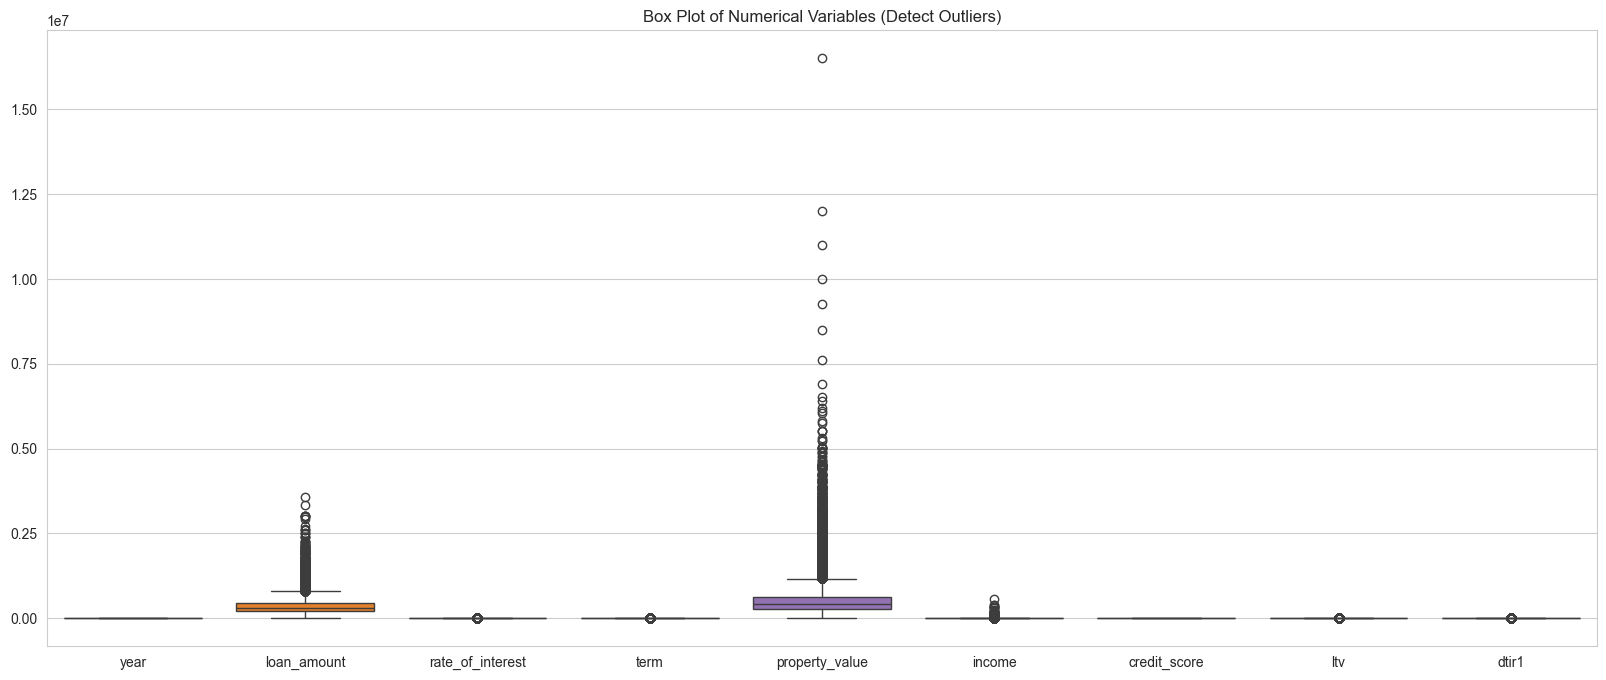

In [43]:
# OUTLIER DETECTION

plt.figure(figsize=(20, 8))
sns.boxplot(data=df[numerical_cols])
plt.title("Box Plot of Numerical Variables (Detect Outliers)")
plt.show()

In [44]:
# OUTLIER HANDLING

outlier_cols = ['loan_amount','property_value', 'income']

for col in outlier_cols:
    # Compute the 95th percentile
    percentile_95 = np.percentile(df[col], 95)

    # Create outlier indicator column
    df[f"{col}_outlier"] = np.where(df[col] > percentile_95, 1, 0)

    # Cap values at 95th percentile
    df[col] = np.where(df[col] > percentile_95, percentile_95, df[col])

print("\nProcessed Data with Outlier Handling:")
df.head()


Processed Data with Outlier Handling:


,year,loan_limit,gender,approv_in_adv,loan_type,loan_purpose,credit_worthiness,open_credit,business_or_commercial,loan_amount,...,co-applicant_credit_type,age,submission_of_application,ltv,region,security_type,dtir1,loan_amount_outlier,property_value_outlier,income_outlier
0,2019,cf,Sex Not Available,nopre,type1,p1,l1,nopc,nob/c,116500.0,...,CIB,25-34,to_inst,98.728814,south,direct,45.0,0,0,0
1,2019,cf,Male,nopre,type2,p1,l1,nopc,b/c,206500.0,...,EXP,55-64,to_inst,NaN,North,direct,NaN,0,0,0
2,2019,cf,Male,pre,type1,p1,l1,nopc,nob/c,406500.0,...,CIB,35-44,to_inst,80.019685,south,direct,46.0,0,0,0
3,2019,cf,Male,nopre,type1,p4,l1,nopc,nob/c,456500.0,...,CIB,45-54,not_inst,69.376900,North,direct,42.0,0,0,0
4,2019,cf,Joint,pre,type1,p1,l1,nopc,nob/c,656500.0,...,EXP,25-34,not_inst,91.886544,North,direct,39.0,1,0,0


/var/folders/gv/2jtg4pvd7_b69lh9vfjbwrth0000gn/T/ipykernel_7532/3434960060.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[col], palette="viridis")


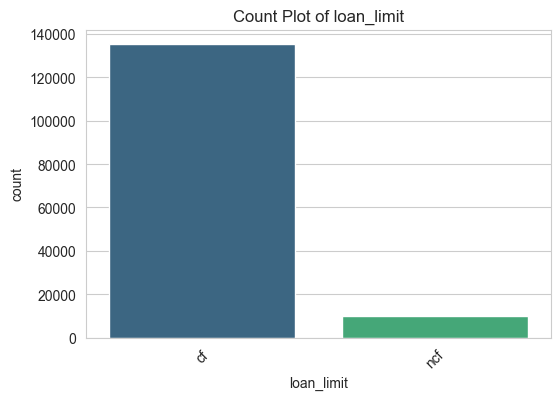

/var/folders/gv/2jtg4pvd7_b69lh9vfjbwrth0000gn/T/ipykernel_7532/3434960060.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[col], palette="viridis")


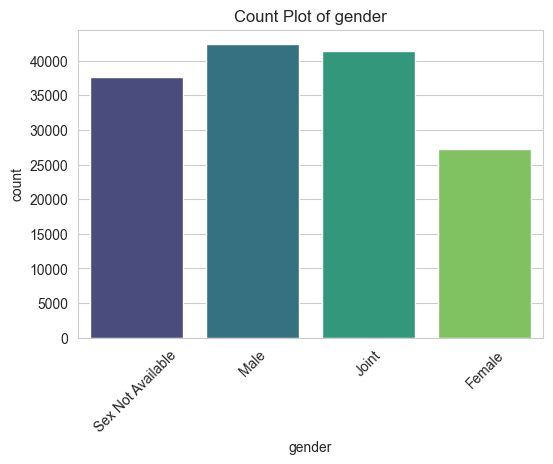

/var/folders/gv/2jtg4pvd7_b69lh9vfjbwrth0000gn/T/ipykernel_7532/3434960060.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[col], palette="viridis")


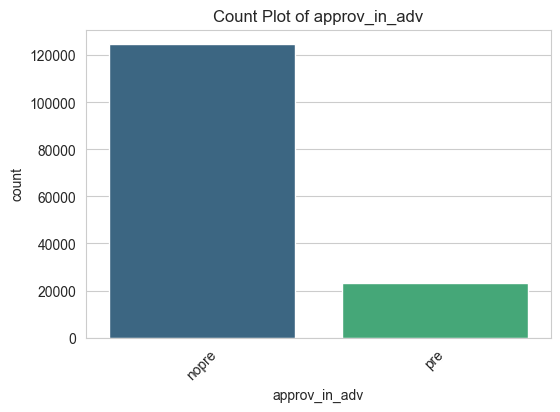

/var/folders/gv/2jtg4pvd7_b69lh9vfjbwrth0000gn/T/ipykernel_7532/3434960060.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[col], palette="viridis")


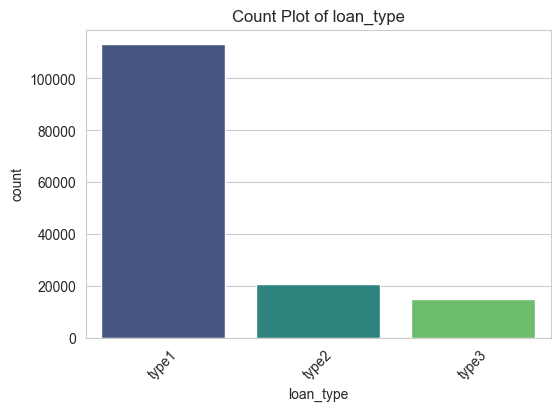

/var/folders/gv/2jtg4pvd7_b69lh9vfjbwrth0000gn/T/ipykernel_7532/3434960060.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[col], palette="viridis")


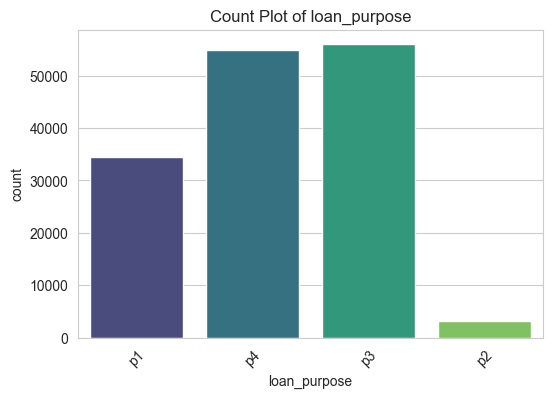

/var/folders/gv/2jtg4pvd7_b69lh9vfjbwrth0000gn/T/ipykernel_7532/3434960060.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[col], palette="viridis")


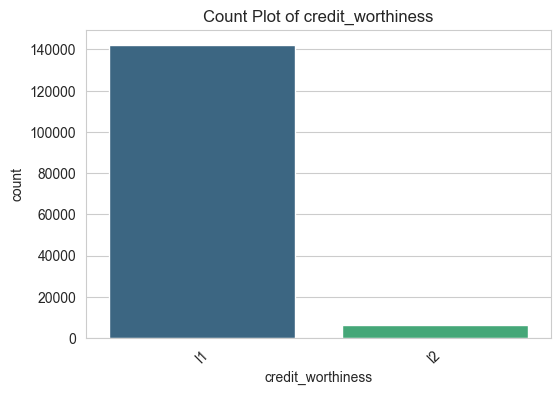

/var/folders/gv/2jtg4pvd7_b69lh9vfjbwrth0000gn/T/ipykernel_7532/3434960060.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[col], palette="viridis")


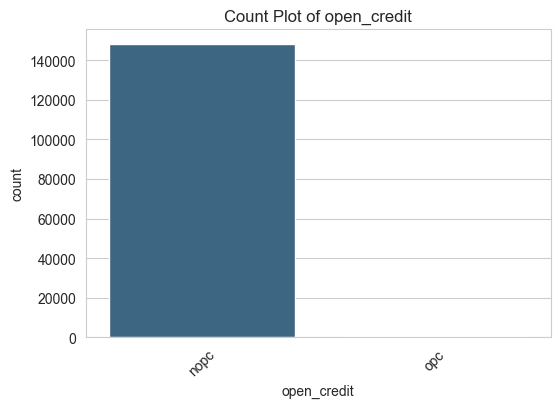

/var/folders/gv/2jtg4pvd7_b69lh9vfjbwrth0000gn/T/ipykernel_7532/3434960060.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[col], palette="viridis")


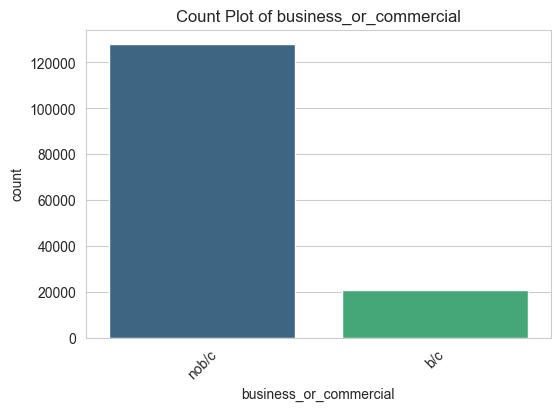

/var/folders/gv/2jtg4pvd7_b69lh9vfjbwrth0000gn/T/ipykernel_7532/3434960060.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[col], palette="viridis")


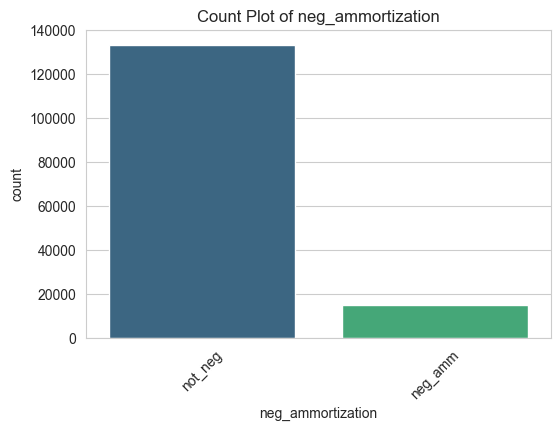

/var/folders/gv/2jtg4pvd7_b69lh9vfjbwrth0000gn/T/ipykernel_7532/3434960060.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[col], palette="viridis")


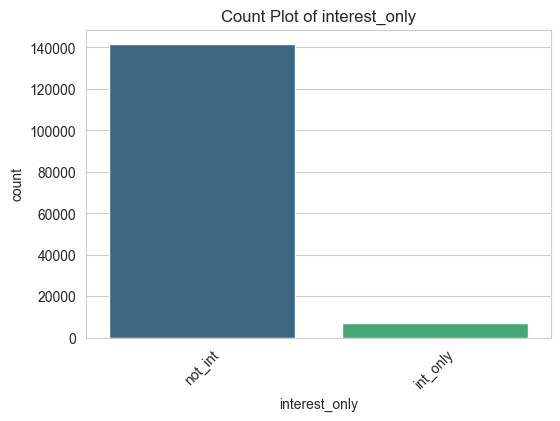

/var/folders/gv/2jtg4pvd7_b69lh9vfjbwrth0000gn/T/ipykernel_7532/3434960060.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[col], palette="viridis")


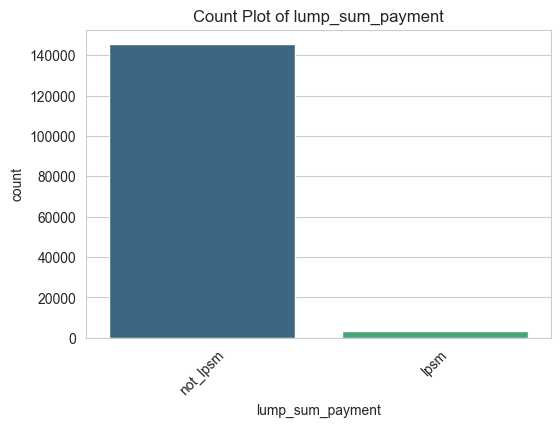

/var/folders/gv/2jtg4pvd7_b69lh9vfjbwrth0000gn/T/ipykernel_7532/3434960060.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[col], palette="viridis")


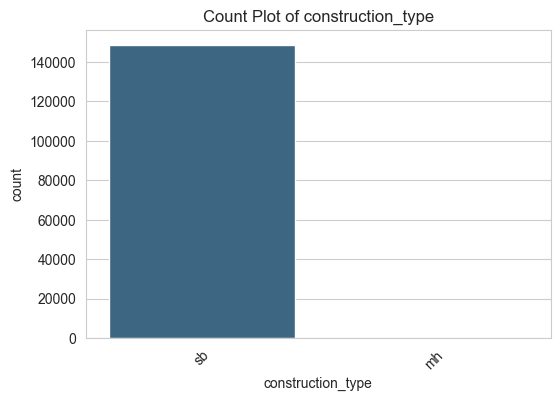

/var/folders/gv/2jtg4pvd7_b69lh9vfjbwrth0000gn/T/ipykernel_7532/3434960060.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[col], palette="viridis")


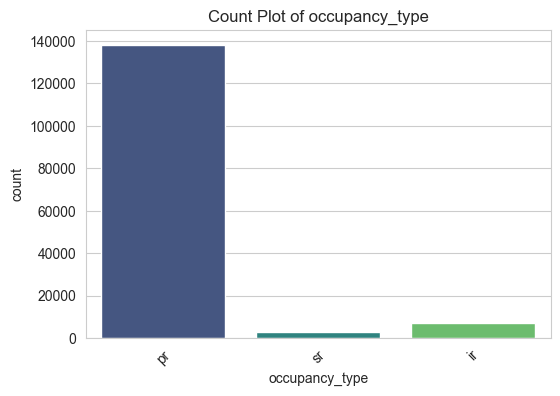

/var/folders/gv/2jtg4pvd7_b69lh9vfjbwrth0000gn/T/ipykernel_7532/3434960060.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[col], palette="viridis")


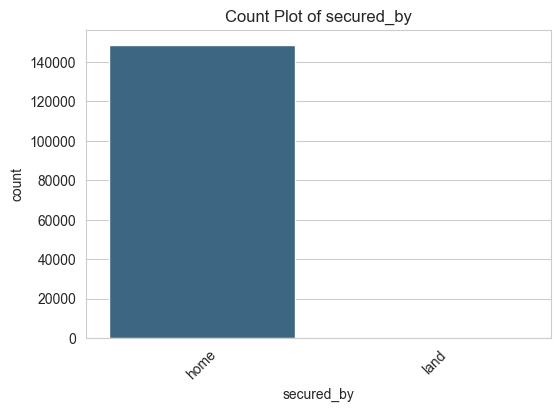

/var/folders/gv/2jtg4pvd7_b69lh9vfjbwrth0000gn/T/ipykernel_7532/3434960060.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[col], palette="viridis")


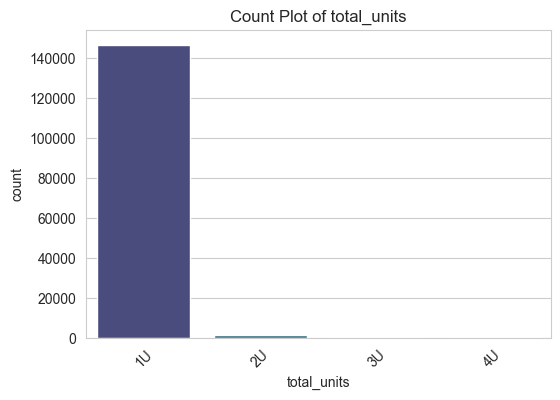

/var/folders/gv/2jtg4pvd7_b69lh9vfjbwrth0000gn/T/ipykernel_7532/3434960060.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[col], palette="viridis")


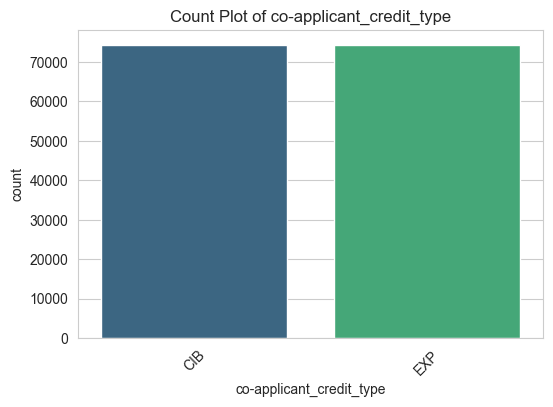

/var/folders/gv/2jtg4pvd7_b69lh9vfjbwrth0000gn/T/ipykernel_7532/3434960060.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[col], palette="viridis")


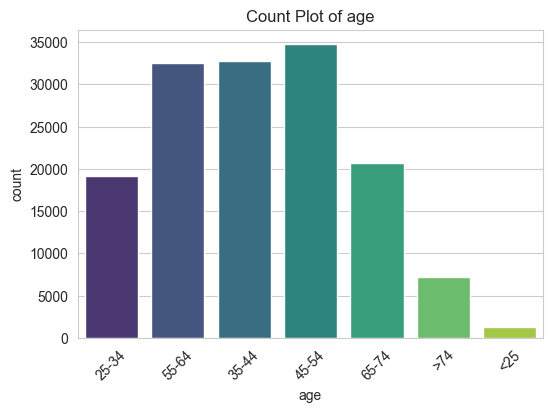

/var/folders/gv/2jtg4pvd7_b69lh9vfjbwrth0000gn/T/ipykernel_7532/3434960060.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[col], palette="viridis")


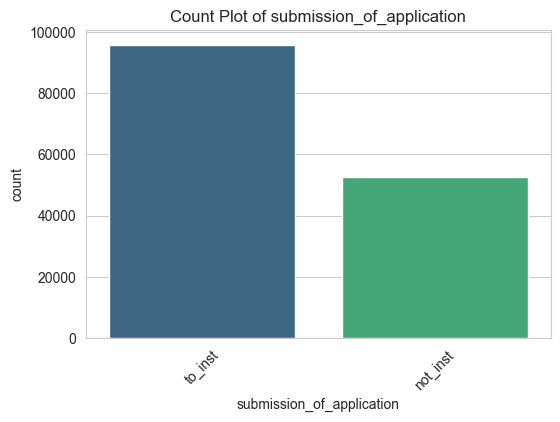

/var/folders/gv/2jtg4pvd7_b69lh9vfjbwrth0000gn/T/ipykernel_7532/3434960060.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[col], palette="viridis")


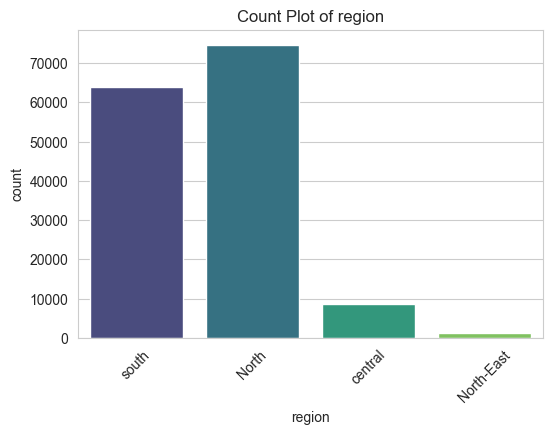

/var/folders/gv/2jtg4pvd7_b69lh9vfjbwrth0000gn/T/ipykernel_7532/3434960060.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[col], palette="viridis")


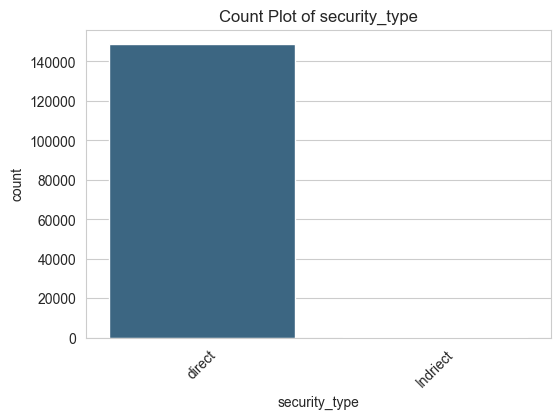

In [45]:
for col in categorical_cols:
    plt.figure(figsize=(6, 4))
    sns.countplot(x=df[col], palette="viridis")
    plt.title(f"Count Plot of {col}")
    plt.xticks(rotation=45)
    plt.show()

#### HANDLING MISSING VALUES

In [46]:
def handle_missing_values(df):
    """
    Handles missing values in a DataFrame:
    - Categorical columns: Impute with mode (most frequent value)
    - Numerical columns: Impute with median
    - Returns the modified DataFrame
    """
    
    # Separate numerical and categorical columns
    categorical_cols = df.select_dtypes(include=['object', 'bool']).columns
    numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns

    # Impute categorical columns with mode
    for col in categorical_cols:
        mode_value = df[col].mode()[0] 
        df[col] = df[col].fillna(mode_value)

    # Impute numerical columns with median
    for col in numerical_cols:
        median_value = df[col].median()  
        df[col] = df[col].fillna(median_value)

    return df 

df_cleaned = handle_missing_values(df)

print("\nAfter Handling Missing Values:")
df_cleaned



After Handling Missing Values:


,year,loan_limit,gender,approv_in_adv,loan_type,loan_purpose,credit_worthiness,open_credit,business_or_commercial,loan_amount,...,co-applicant_credit_type,age,submission_of_application,ltv,region,security_type,dtir1,loan_amount_outlier,property_value_outlier,income_outlier
0,2019,cf,Sex Not Available,nopre,type1,p1,l1,nopc,nob/c,116500.0,...,CIB,25-34,to_inst,98.728814,south,direct,45.0,0,0,0
1,2019,cf,Male,nopre,type2,p1,l1,nopc,b/c,206500.0,...,EXP,55-64,to_inst,75.135870,North,direct,39.0,0,0,0
2,2019,cf,Male,pre,type1,p1,l1,nopc,nob/c,406500.0,...,CIB,35-44,to_inst,80.019685,south,direct,46.0,0,0,0
3,2019,cf,Male,nopre,type1,p4,l1,nopc,nob/c,456500.0,...,CIB,45-54,not_inst,69.376900,North,direct,42.0,0,0,0
4,2019,cf,Joint,pre,type1,p1,l1,nopc,nob/c,656500.0,...,EXP,25-34,not_inst,91.886544,North,direct,39.0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
148665,2019,cf,Sex Not Available,nopre,type1,p3,l1,nopc,nob/c,436500.0,...,EXP,55-64,to_inst,71.792763,south,direct,48.0,0,0,0
148666,2019,cf,Male,nopre,type1,p1,l1,nopc,nob/c,586500.0,...,CIB,25-34,not_inst,74.428934,south,direct,15.0,0,0,0
148667,2019,cf,Male,nopre,type1,p4,l1,nopc,nob/c,446500.0,...,EXP,45-54,not_inst,61.332418,North,direct,49.0,0,0,0
148668,2019,cf,Female,nopre,type1,p4,l1,nopc,nob/c,196500.0,...,EXP,55-64,to_inst,70.683453,North,direct,29.0,0,0,0


In [47]:
# RE VALIDATE MISSING VALUES IN EACH COLUMN

missing_percentage = (df.isnull().sum() / len(df)) * 100

print(missing_percentage)

year                         0.0
loan_limit                   0.0
gender                       0.0
approv_in_adv                0.0
loan_type                    0.0
loan_purpose                 0.0
credit_worthiness            0.0
open_credit                  0.0
business_or_commercial       0.0
loan_amount                  0.0
rate_of_interest             0.0
term                         0.0
neg_ammortization            0.0
interest_only                0.0
lump_sum_payment             0.0
property_value               0.0
construction_type            0.0
occupancy_type               0.0
secured_by                   0.0
total_units                  0.0
income                       0.0
credit_score                 0.0
co-applicant_credit_type     0.0
age                          0.0
submission_of_application    0.0
ltv                          0.0
region                       0.0
security_type                0.0
dtir1                        0.0
loan_amount_outlier          0.0
property_v

#### CORRELATION & MULTICOLLINEARITY HANDLING

Correlation Matrix:
                        year  loan_amount  rate_of_interest      term  \
year                     NaN          NaN               NaN       NaN   
loan_amount              NaN     1.000000         -0.135067  0.190256   
rate_of_interest         NaN    -0.135067          1.000000  0.182857   
term                     NaN     0.190256          0.182857  1.000000   
property_value           NaN     0.643215         -0.102772  0.043050   
income                   NaN     0.403183         -0.014341 -0.057391   
credit_score             NaN     0.004356         -0.001341 -0.003167   
ltv                      NaN     0.046186         -0.002258  0.101079   
dtir1                    NaN     0.021693          0.029836  0.106338   
loan_amount_outlier      NaN     0.473109         -0.011648  0.058993   
property_value_outlier   NaN          NaN               NaN       NaN   
income_outlier           NaN          NaN               NaN       NaN   

                        proper

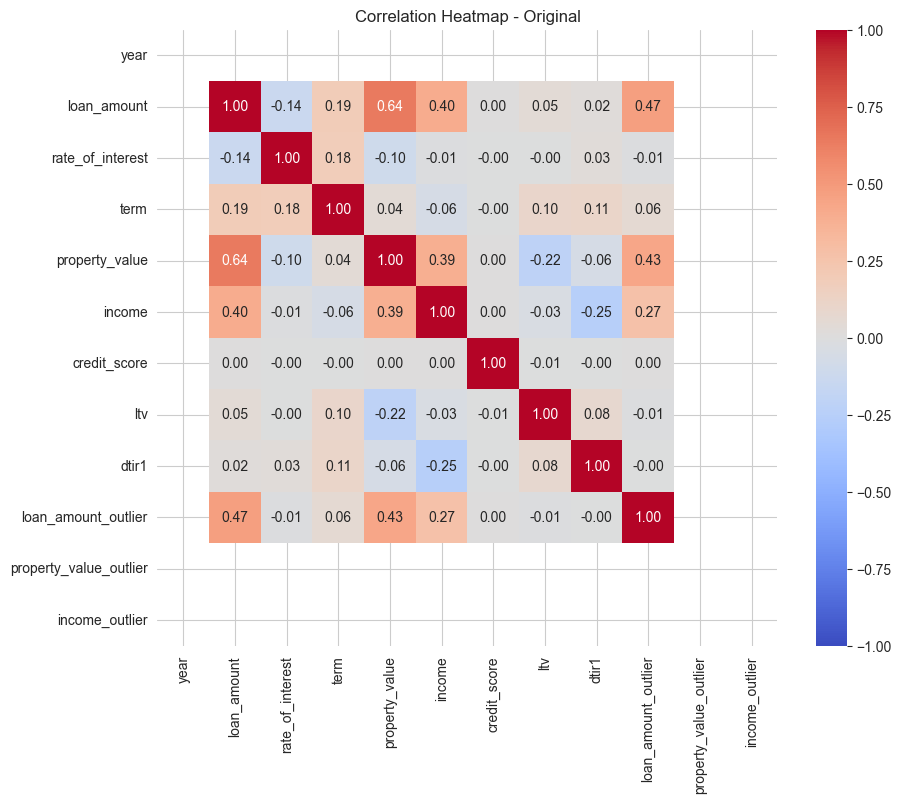

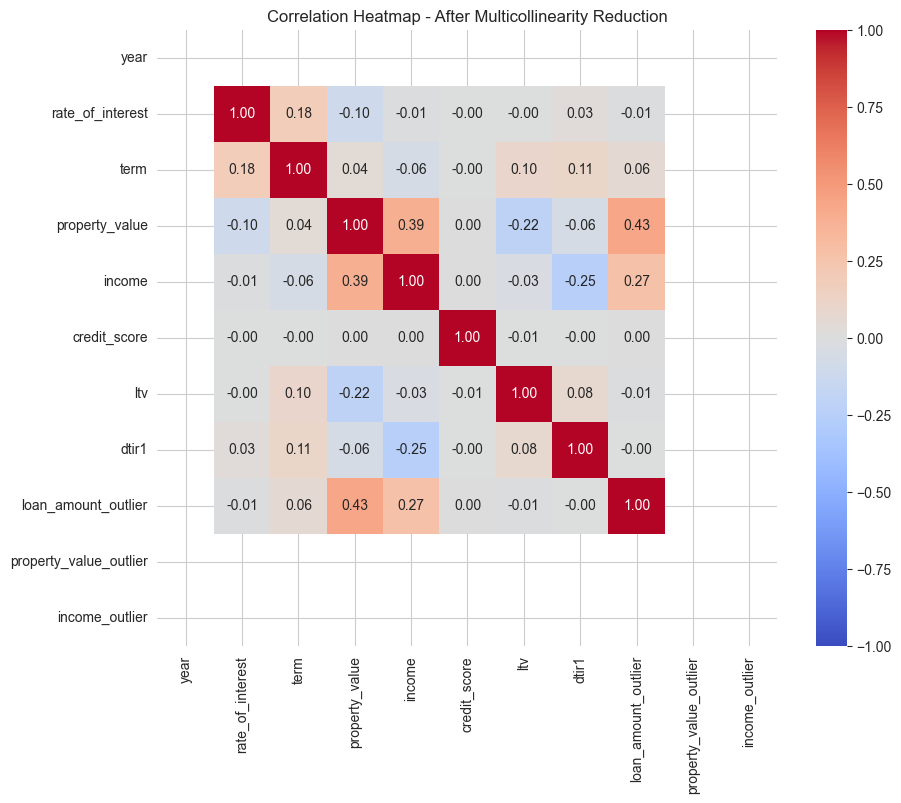

In [48]:
def analyze_and_handle_correlations(df, correlation_threshold=0.8):
    
    # Calculate correlation matrix for numerical columns only
    numeric_df = df.select_dtypes(include=['int64', 'float64', 'int32', 'float32'])
    corr_matrix = numeric_df.corr()
    
    print("Correlation Matrix:")
    print(corr_matrix)
    print("\n")
    
    # Find and print highly correlated pairs
    print(f"Highly Correlated Pairs (above {correlation_threshold}):")
    correlated_pairs = []
    for i in range(len(corr_matrix.columns)):
        for j in range(i):
            if abs(corr_matrix.iloc[i, j]) > correlation_threshold:
                pair = (corr_matrix.columns[i], corr_matrix.columns[j], 
                       corr_matrix.iloc[i, j])
                correlated_pairs.append(pair)
                print(f"{pair[0]} - {pair[1]}: {pair[2]:.3f}")
    
    # Handle multicollinearity
    columns_to_drop = set()
    seen = set()
    
    for col1, col2, corr_value in correlated_pairs:
        if col1 not in seen and col2 not in seen:
            columns_to_drop.add(col2)
            seen.add(col1)
        elif col1 not in seen:
            columns_to_drop.add(col1)
        elif col2 not in seen:
            columns_to_drop.add(col2)
    
    df_reduced = df.drop(columns=list(columns_to_drop))
    
    print("\nDropped columns to reduce multicollinearity:")
    print(list(columns_to_drop))
    
    # Verify correlations in reduced DataFrame
    if len(columns_to_drop) > 0:
        reduced_numeric_df = df_reduced.select_dtypes(include=['int64', 'float64', 'int32', 'float32'])
        reduced_corr_matrix = reduced_numeric_df.corr()
        print("\nCorrelation Matrix after dropping columns:")
        print(reduced_corr_matrix)
    
    return df_reduced, list(columns_to_drop)

df_reduced, dropped_columns = analyze_and_handle_correlations(df, correlation_threshold=0.60)

def plot_correlation_heatmap(df, title="Correlation Heatmap"):
    numeric_df = df.select_dtypes(include=['int64', 'float64', 'int32', 'float32'])
    corr_matrix = numeric_df.corr()
            
    plt.figure(figsize=(10, 8))
    sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, 
                vmin=-1, vmax=1, fmt='.2f')
    plt.title(title)
    plt.show()

# Plot correlation heatmaps
plot_correlation_heatmap(df, "Correlation Heatmap - Original")
plot_correlation_heatmap(df_reduced, "Correlation Heatmap - After Multicollinearity Reduction")

In [49]:
# After your encoding step
df_reduced, dropped_columns = analyze_and_handle_correlations(df)

Correlation Matrix:
                        year  loan_amount  rate_of_interest      term  \
year                     NaN          NaN               NaN       NaN   
loan_amount              NaN     1.000000         -0.135067  0.190256   
rate_of_interest         NaN    -0.135067          1.000000  0.182857   
term                     NaN     0.190256          0.182857  1.000000   
property_value           NaN     0.643215         -0.102772  0.043050   
income                   NaN     0.403183         -0.014341 -0.057391   
credit_score             NaN     0.004356         -0.001341 -0.003167   
ltv                      NaN     0.046186         -0.002258  0.101079   
dtir1                    NaN     0.021693          0.029836  0.106338   
loan_amount_outlier      NaN     0.473109         -0.011648  0.058993   
property_value_outlier   NaN          NaN               NaN       NaN   
income_outlier           NaN          NaN               NaN       NaN   

                        proper

#### TRAIN TEST SPLIT

In [50]:
# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    df_reduced,          # Features
    y,                   # Target
    test_size=0.25,      # 25% for testing, 75% for training
    random_state=42      # For reproducibility
)

# Verify the split
print("Dataset Split Summary:")
print(f"Total samples: {len(df_reduced)}")
print(f"Training set: {len(X_train)} samples ({len(X_train)/len(df_reduced)*100:.1f}%)")
print(f"Testing set: {len(X_test)} samples ({len(X_test)/len(df_reduced)*100:.1f}%)")

print("\nDataset Shapes:")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

Dataset Split Summary:
Total samples: 148670
Training set: 111502 samples (75.0%)
Testing set: 37168 samples (25.0%)

Dataset Shapes:
X_train shape: (111502, 32)
X_test shape: (37168, 32)
y_train shape: (111502,)
y_test shape: (37168,)


In [51]:
y_test.value_counts()

status
0    28050
1     9118
Name: count, dtype: int64

CATEGORICAL ENCODING - ONE HOT & TARGET ENCODING

In [52]:

def encode_categorical_features(X_train, y_train, X_test=None):
    # Make copies to avoid modifying originals
    X_train_encoded = X_train.copy()
    X_test_encoded = X_test.copy() if X_test is not None else None
    
    # Identify categorical columns
    categorical_cols = X_train_encoded.select_dtypes(include=['object', 'bool']).columns.tolist()
    
    for col in categorical_cols:
        unique_values = X_train_encoded[col].nunique()
        if unique_values < 5:
            # One-hot encoding with integers (1 and 0)
            X_train_encoded = pd.get_dummies(X_train_encoded, columns=[col], prefix=col, drop_first=True, dtype=int)
            if X_test_encoded is not None:
                X_test_encoded = pd.get_dummies(X_test_encoded, columns=[col], prefix=col, drop_first=True, dtype=int)
                # Align columns in case X_test has fewer categories
                X_test_encoded = X_test_encoded.reindex(columns=X_train_encoded.columns, fill_value=0)
        else:
            # Target encoding using only training data
            temp_df = pd.DataFrame({'feature': X_train_encoded[col], 'target': y_train})
            target_means = temp_df.groupby('feature')['target'].mean()
            # Apply mapping to training set
            X_train_encoded[col] = X_train_encoded[col].map(target_means)
            # Apply the same mapping to test set (use training means to avoid leakage)
            if X_test_encoded is not None:
                X_test_encoded[col] = X_test_encoded[col].map(target_means).fillna(target_means.mean())
    
    return X_train_encoded, X_test_encoded


# Encode training and test sets
X_train_encoded, X_test_encoded = encode_categorical_features(X_train, y_train, X_test)

print("\nAfter Encoding (Training Set):")
print(X_train_encoded.head())
print("\nAfter Encoding (Test Set):")
print(X_test_encoded.head())


After Encoding (Training Set):
        year  loan_amount  rate_of_interest   term  property_value   income  \
123891  2019     656500.0             4.375  360.0       1258000.0  10560.0   
15938   2019     266500.0             4.375  360.0        338000.0   3240.0   
108267  2019     446500.0             3.625  360.0        608000.0   5760.0   
88902   2019     296500.0             3.625  240.0        458000.0   5820.0   
61172   2019     366500.0             3.625  360.0        628000.0   5160.0   

        credit_score       age        ltv  dtir1  ...  secured_by_land  \
123891           625  0.244545  57.750397   30.0  ...                0   
15938            567  0.221601  78.846154   44.0  ...                0   
108267           692  0.259332  73.437500   39.0  ...                0   
88902            893  0.259332  64.737991   36.0  ...                0   
61172            719  0.296467  58.359873   38.0  ...                0   

        total_units_2U  total_units_3U  total_un

#### MODEL TRAINING

##### LOGISTIC REGRESSION & VALIDATION

Logistic Regression Model Performance:
Accuracy: 0.7546814464055102

Classification Report:
              precision    recall  f1-score   support

           0       0.75      1.00      0.86     28050
           1       0.00      0.00      0.00      9118

    accuracy                           0.75     37168
   macro avg       0.38      0.50      0.43     37168
weighted avg       0.57      0.75      0.65     37168


Confusion Matrix:
[[28050     0]
 [ 9118     0]]


/Users/kavyakandhakatla/projects/machine_learning/tf_venv/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/Users/kavyakandhakatla/projects/machine_learning/tf_venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/kavyakandhakatla/projects/machine_learning/tf_venv/lib/python3.10/site-

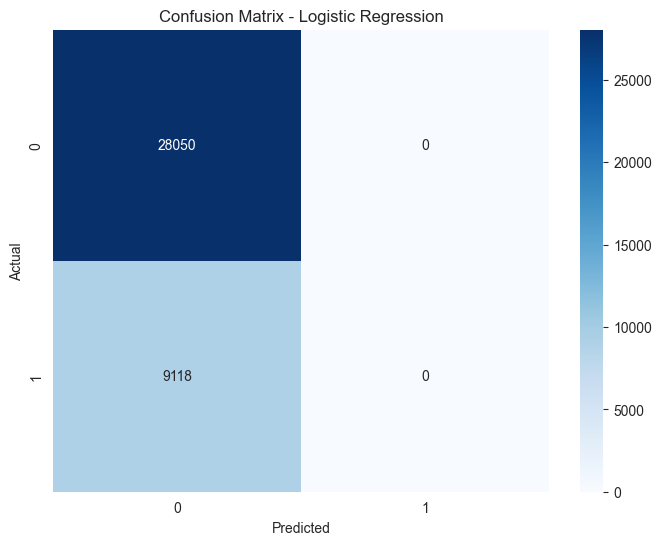

In [53]:
# Initialize and train the logistic regression model
log_reg = LogisticRegression(max_iter=1000, random_state=42) 
log_reg.fit(X_train_encoded, y_train)

# Make predictions on the test set
y_pred = log_reg.predict(X_test_encoded)

# Print classification metrics
print("Logistic Regression Model Performance:")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Compute and display confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(conf_matrix)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', 
            xticklabels=np.unique(y), yticklabels=np.unique(y))
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### KNN MODEL & VALIDATION


KNN Model Performance:
Accuracy: 0.8473687042617305

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.98      0.91     28050
           1       0.88      0.44      0.58      9118

    accuracy                           0.85     37168
   macro avg       0.86      0.71      0.75     37168
weighted avg       0.85      0.85      0.83     37168



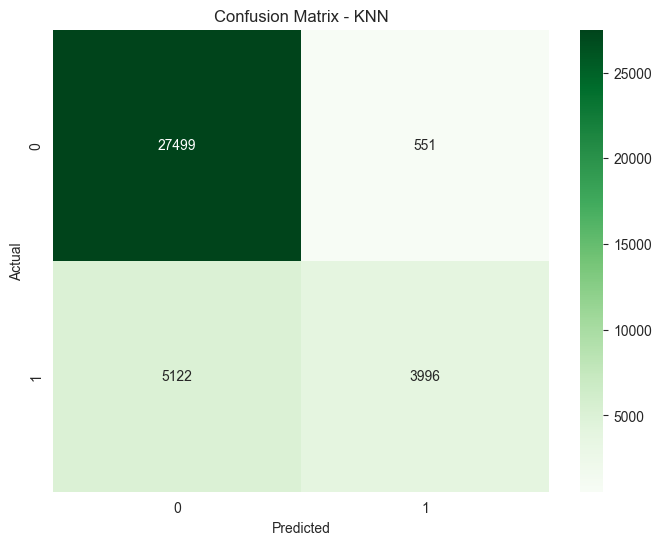

In [69]:
#%%
#### KNN MODEL


from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

#%%
# Initialize the KNN model
knn_model = KNeighborsClassifier(
    n_neighbors=10,    # Number of neighbors to use
    metric='minkowski', # Distance metric ('minkowski' = Euclidean by default)
    p=2               # p=2 for Euclidean distance
)

# Train the model
knn_model.fit(X_train_encoded, y_train)

# Make predictions
y_pred_knn = knn_model.predict(X_test_encoded)

#%%
# Evaluate the model
print("\nKNN Model Performance:")
print("Accuracy:", accuracy_score(y_test, y_pred_knn))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_knn))

#%%
# Confusion Matrix
conf_matrix_knn = confusion_matrix(y_test, y_pred_knn)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_knn, annot=True, fmt='d', cmap='Greens',
            xticklabels=np.unique(y_test), yticklabels=np.unique(y_test))
plt.title("Confusion Matrix - KNN")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


##### RANDOM FORESTS MODEL & VALIDATION

Random Forest Model Performance:
Accuracy: 0.9344328454584588

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.96      0.96     28050
           1       0.89      0.84      0.86      9118

    accuracy                           0.93     37168
   macro avg       0.92      0.90      0.91     37168
weighted avg       0.93      0.93      0.93     37168


Confusion Matrix:
[[27053   997]
 [ 1440  7678]]


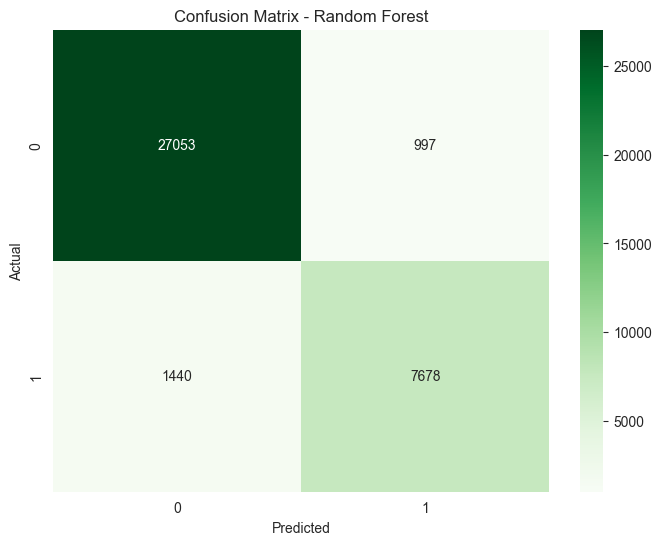


Top 5 Feature Importances:
rate_of_interest: 0.3335
ltv: 0.1460
property_value: 0.1071
dtir1: 0.0982
income: 0.0548


In [55]:
# Initialize and train the Random Forest model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)  
rf_model.fit(X_train_encoded, y_train)

# Make predictions on the test set
y_pred_rf = rf_model.predict(X_test_encoded)

# Print classification metrics
print("Random Forest Model Performance:")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

# Compute and display confusion matrix
conf_matrix_rf = confusion_matrix(y_test, y_pred_rf)
print("\nConfusion Matrix:")
print(conf_matrix_rf)

# Visualize confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_rf, annot=True, fmt='d', cmap='Greens', 
            xticklabels=np.unique(y), yticklabels=np.unique(y))
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Feature importance
feature_importance = rf_model.feature_importances_
feature_names = X_train_encoded.columns  
sorted_idx = np.argsort(feature_importance)[::-1]

print("\nTop 5 Feature Importances:")
for i in range(min(5, len(feature_names))):
    print(f"{feature_names[sorted_idx[i]]}: {feature_importance[sorted_idx[i]]:.4f}")

##### XGBOOST MODEL & VALIDATION

XGBoost Model Performance:
Accuracy: 0.9355897546276367

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.96      0.96     28050
           1       0.87      0.87      0.87      9118

    accuracy                           0.94     37168
   macro avg       0.91      0.91      0.91     37168
weighted avg       0.94      0.94      0.94     37168


Confusion Matrix:
[[26813  1237]
 [ 1157  7961]]


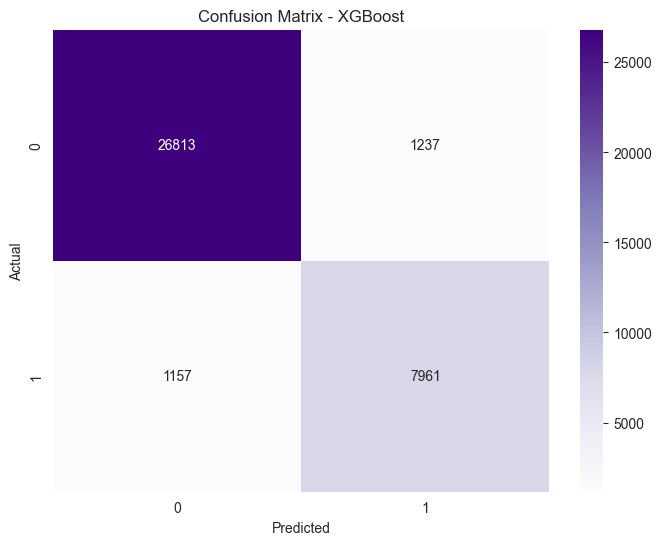


Top 5 Feature Importances:
gender: 0.7683
dtir1: 0.0344
business_or_commercial: 0.0282
loan_amount: 0.0241
region: 0.0225


In [56]:
# Initialize and train the XGBoost model
xgb_model = xgb.XGBClassifier(
    n_estimators=100,        # Number of boosting rounds (trees)
    max_depth=6,             # Maximum depth of each tree
    learning_rate=0.1,       # Step size shrinkage
    random_state=42,         # For reproducibility
    eval_metric='logloss'    # Loss function for binary classification (adjust if multi-class)
)
xgb_model.fit(X_train_encoded, y_train)

# Make predictions on the test set
y_pred_xgb = xgb_model.predict(X_test_encoded)

# Print classification metrics
print("XGBoost Model Performance:")
print("Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb))

# Compute and display confusion matrix
conf_matrix_xgb = confusion_matrix(y_test, y_pred_xgb)
print("\nConfusion Matrix:")
print(conf_matrix_xgb)

# Visualize confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_xgb, annot=True, fmt='d', cmap='Purples', 
            xticklabels=np.unique(y), yticklabels=np.unique(y))
plt.title("Confusion Matrix - XGBoost")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Optional: Feature importance
feature_importance = xgb_model.feature_importances_
feature_names = X_train.columns  # Assuming X_train is a DataFrame with column names
sorted_idx = np.argsort(feature_importance)[::-1]

print("\nTop 5 Feature Importances:")
for i in range(min(5, len(feature_names))):
    print(f"{feature_names[sorted_idx[i]]}: {feature_importance[sorted_idx[i]]:.4f}")

##### CROSS VALIDATION

In [57]:
# Custom transformer for our encoding function
class CategoricalEncoder(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        self.target_values_ = y
        return self
    
    def transform(self, X):
        X_copy = X.copy()
        categorical_cols = X_copy.select_dtypes(include=['object', 'bool']).columns.tolist()
        for col in categorical_cols:
            unique_values = X_copy[col].nunique()
            if unique_values < 5:
                X_copy = pd.get_dummies(X_copy, columns=[col], prefix=col, drop_first=True, dtype=int)
            else:
                temp_df = pd.DataFrame({'feature': X_copy[col], 'target': self.target_values_})
                target_means = temp_df.groupby('feature')['target'].mean()
                X_copy[col] = X_copy[col].map(target_means)
        return X_copy

# Define the pipeline
pipeline = Pipeline([
    ('encoder', CategoricalEncoder()),
    ('classifier', xgb.XGBClassifier(n_estimators=100, max_depth=6, learning_rate=0.1, random_state=42, eval_metric='logloss'))
])

# Run cross-validation
scores = cross_val_score(pipeline, df, y, cv=5, scoring='accuracy')
print("Cross-validation scores:", scores)
print("Mean CV accuracy:", scores.mean())

Cross-validation scores: [0.9371763  0.9377144  0.93192978 0.93115625 0.93361135]
Mean CV accuracy: 0.9343176161969463


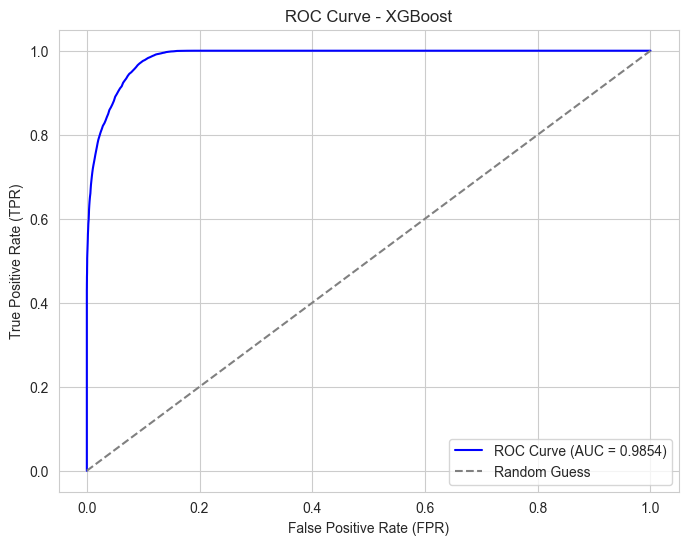

AUC Score: 0.9854


In [58]:
y_pred_proba = rf_model.predict_proba(X_test_encoded)[:, 1]  

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

# Calculate AUC score
auc_score = roc_auc_score(y_test, y_pred_proba)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label=f'ROC Curve (AUC = {auc_score:.4f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Random Guess')
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('ROC Curve - XGBoost')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

# Print AUC score
print(f"AUC Score: {auc_score:.4f}")

In [59]:
#%%
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

def plot_roc_curve(model, X_test, y_test, model_name="Model"):
    """
    Plots ROC curve and prints AUC score for a given trained model.
    
    Args:
        model: Trained classification model
        X_test: Test features
        y_test: Test labels
        model_name (str): Name of the model (for labeling)

    Returns:
        None
    """
    # Get predicted probabilities
    y_pred_proba = model.predict_proba(X_test)[:, 1]
    
    # Calculate ROC curve
    fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
    
    # Calculate AUC score
    auc_score = roc_auc_score(y_test, y_pred_proba)
    
    # Plot ROC curve
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='blue', label=f'{model_name} (AUC = {auc_score:.4f})')
    plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Random Guess')
    plt.xlabel('False Positive Rate (FPR)')
    plt.ylabel('True Positive Rate (TPR)')
    plt.title(f'ROC Curve - {model_name}')
    plt.legend(loc='lower right')
    plt.grid(True)
    plt.show()
    
    # Print AUC score
    print(f"{model_name} AUC Score: {auc_score:.4f}")


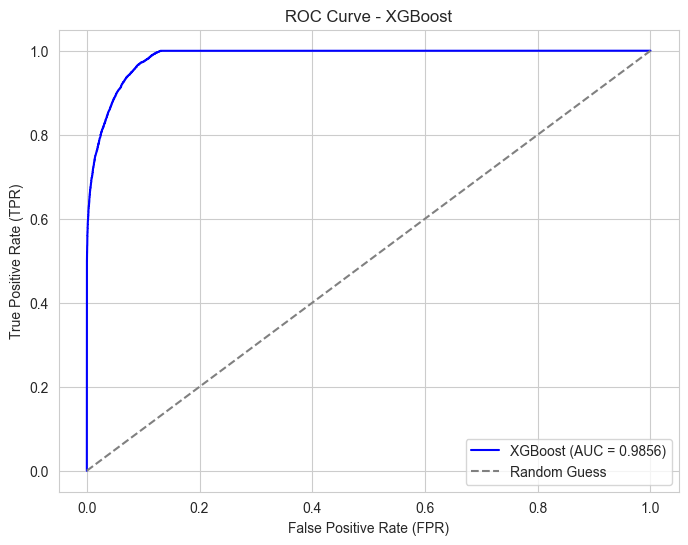

XGBoost AUC Score: 0.9856


In [66]:
plot_roc_curve(xgb_model, X_test_encoded, y_test, model_name="XGBoost")

### MODEL COMPARISON

                 Model  Accuracy  Precision    Recall  F1-Score
0  Logistic Regression  0.754681   0.000000  0.000000  0.000000
1  K-Nearest Neighbors  0.835773   0.774199  0.466659  0.582318
2        Random Forest  0.934433   0.885072  0.842071  0.863036
3              XGBoost  0.935590   0.865514  0.873108  0.869295


/Users/kavyakandhakatla/projects/machine_learning/tf_venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/var/folders/gv/2jtg4pvd7_b69lh9vfjbwrth0000gn/T/ipykernel_7532/1261037406.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Model", y=metric, data=results_df, ax=ax, palette="Set2")
/var/folders/gv/2jtg4pvd7_b69lh9vfjbwrth0000gn/T/ipykernel_7532/1261037406.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Model", y=metric, data

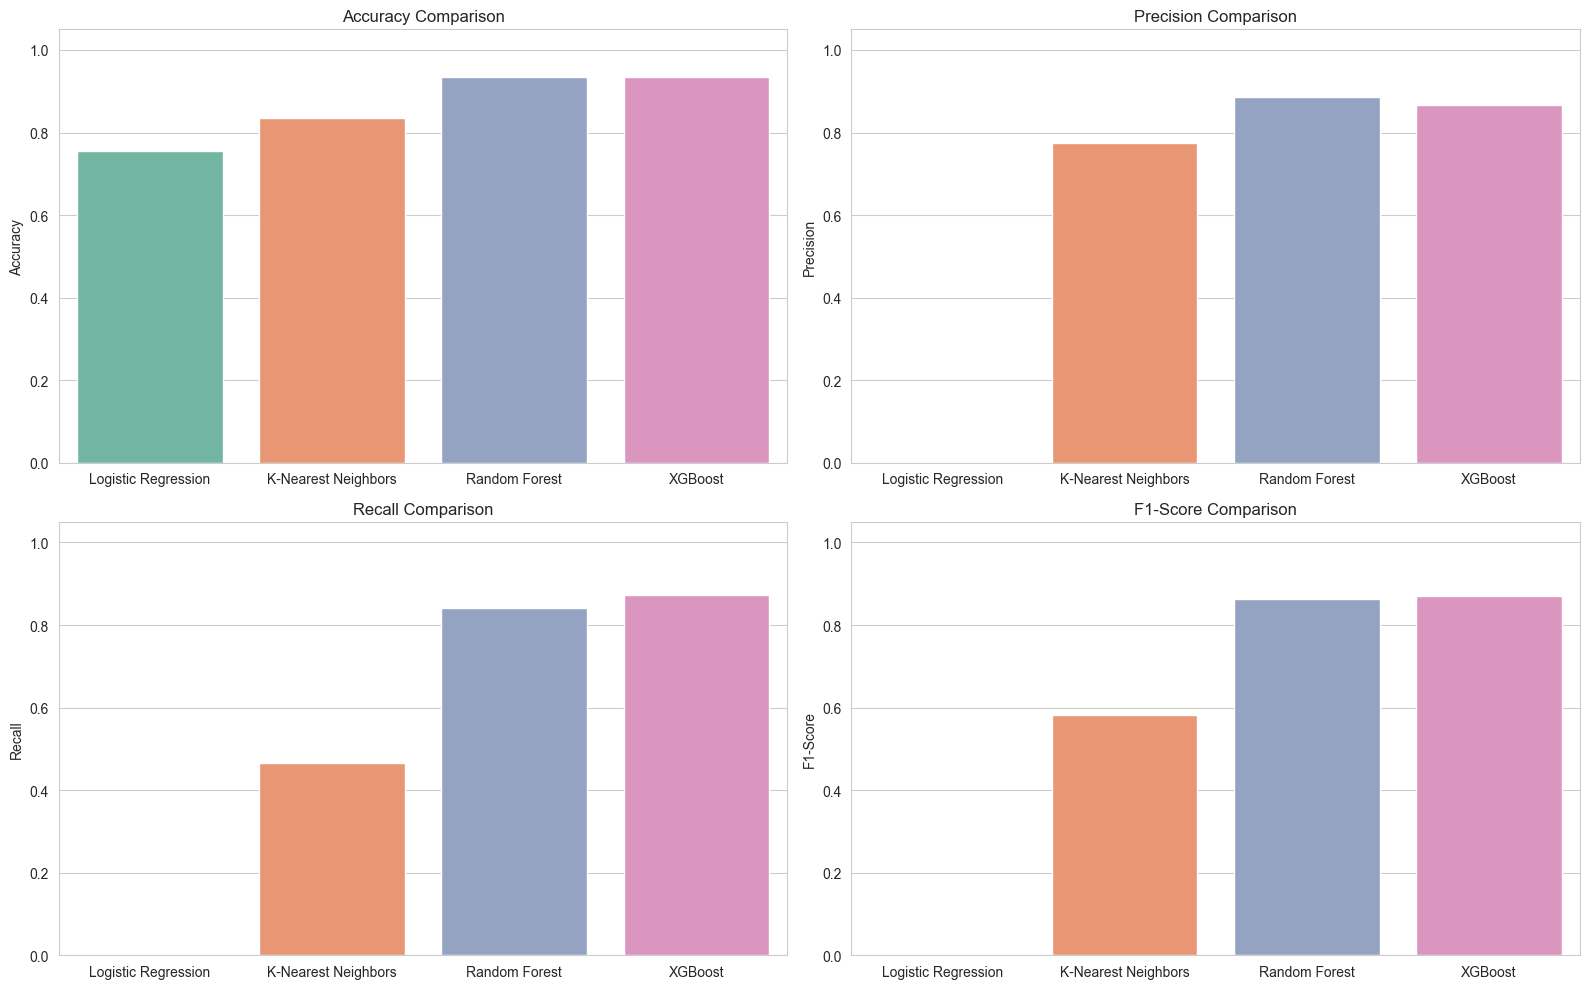

In [61]:
#%%

# Collect metrics for each model
models = {
    "Logistic Regression": y_pred,
    "K-Nearest Neighbors": y_pred_knn,
    "Random Forest": y_pred_rf,
    "XGBoost": y_pred_xgb
}

# Initialize lists to store metrics
model_names = []
accuracies = []
precisions = []
recalls = []
f1_scores = []

for model_name, predictions in models.items():
    model_names.append(model_name)
    accuracies.append(accuracy_score(y_test, predictions))
    precisions.append(precision_score(y_test, predictions, average='binary'))  # assuming binary classification
    recalls.append(recall_score(y_test, predictions, average='binary'))
    f1_scores.append(f1_score(y_test, predictions, average='binary'))

# Create a DataFrame for easier plotting
results_df = pd.DataFrame({
    "Model": model_names,
    "Accuracy": accuracies,
    "Precision": precisions,
    "Recall": recalls,
    "F1-Score": f1_scores
})

print(results_df)

#%%
# Plot comparison
metrics = ["Accuracy", "Precision", "Recall", "F1-Score"]

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

for idx, metric in enumerate(metrics):
    ax = axes[idx//2, idx%2]
    sns.barplot(x="Model", y=metric, data=results_df, ax=ax, palette="Set2")
    ax.set_title(f"{metric} Comparison")
    ax.set_ylim(0, 1.05)  # because scores are between 0 and 1
    ax.set_ylabel(metric)
    ax.set_xlabel("")

plt.tight_layout()
plt.show()
